In [184]:
import time

In [185]:
start_time = time.time()

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import plotly.express as px
import seaborn as sns

from scipy.stats import skew
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from astropy.timeseries import LombScargle

In [187]:
data = []
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

def to_float(x):
    if x == "-":
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

with open("list.dat", "r") as f:
    for line in f:
        parts = line.split()
        # Ignorar líneas vacías
        if len(parts) < 5:
            continue
        obj_id = parts[0]
        ra = parts[1]
        dec = parts[2]
        # Buscar inicio de columnas numéricas
        first_num = None
        for i in range(3, len(parts)):
            if is_float(parts[i]) or parts[i] == "-":
                first_num = i
                break
        if first_num is None:
            continue
        # Clasificaciones
        class_parts = parts[3:first_num]
        tipo1 = class_parts[0] if len(class_parts) > 0 else None
        tipo2 = class_parts[1] if len(class_parts) > 1 else None
        # Extraer columnas de forma segura
        mag_I = to_float(parts[first_num]) if len(parts) > first_num else np.nan
        mag_V = to_float(parts[first_num + 1]) if len(parts) > first_num + 1 else np.nan
        periodo = to_float(parts[first_num + 2]) if len(parts) > first_num + 2 else np.nan
        amplitud = to_float(parts[first_num + 3]) if len(parts) > first_num + 3 else np.nan
        data.append([obj_id,ra,dec,tipo1,tipo2,mag_I,mag_V,periodo,amplitud])

df = pd.DataFrame(data, columns=["ID","RA","DEC","Tipo","Subtipo","I","V","Periodo","Amplitud"])
print(df.head())
print(df.shape)

               ID           RA          DEC   Tipo Subtipo       I       V  \
0   LMC563.16.842  05:46:55.53  -66:30:47.6  OTHER     NaN  18.925  18.981   
1  LMC563.16.1142  05:46:57.17  -66:24:53.9  RRLYR    RRab  19.091  19.745   
2     LMC563.16.8  05:46:57.78  -66:26:43.4    LPV   OSARG  14.662  16.383   
3  LMC563.16.9286  05:46:59.24  -66:18:01.0    ECL     NaN  18.690  18.808   
4  LMC563.16.2137  05:47:00.94  -66:25:36.0  OTHER     NaN  19.526  19.529   

      Periodo  Amplitud  
0    1.850940     0.069  
1    0.494447     0.839  
2  369.000000     0.045  
3    0.972667     0.264  
4    0.850470     0.142  
(6789, 9)


In [188]:
conteo_clases = df['Tipo'].value_counts()
print("\n" + "="*40)
print("RESUMEN DE ESTRELLAS POR CLASE PRINCIPAL")
print("="*40)
for clase, cantidad in conteo_clases.items():
    print(f"{clase:<15} : {cantidad:>8} objetos")
print("-" * 40)
print(f"{'TOTAL':<15} : {conteo_clases.sum():>8} objetos")
print("="*40)


RESUMEN DE ESTRELLAS POR CLASE PRINCIPAL
LPV             :     2799 objetos
OTHER           :     1473 objetos
ECL             :     1376 objetos
RRLYR           :      686 objetos
DSCT            :      159 objetos
ELL             :      156 objetos
DCEP            :      132 objetos
T2CEP           :        5 objetos
ACEP            :        3 objetos
----------------------------------------
TOTAL           :     6789 objetos


Pulsadores radiales(RRKYR, DSCUTI, DCEPHEID, T2CEPHEID, ANOMALOUSCEPHEID)

En su mayoría, pulsan con menos de 20 días de periodo, aunque algunas lo hacen por más, y las cefeidas clásicas se reportan a más de 100 días. 


Todas tienen varios modos de oscilación, 


Delta Scuti variables are fainter, have shorter pulsation periods, and smaller masses than classical Cepheids, but both groups obey the same period-luminosity relation and it is simply a matter of convention which period defines a boundary between them.


Además, todas son "toboganes" hacia la derecha

LPVARIABLES

OTHER

BINARYECLIPSANTES, ELLIPSOIDALES

Iguales, o similares, porque las binarias eclipsantes tienen un eclipse grande y otro más pequeño, y lo mismo pasa con las elipsoidales. Mientras que con las unas es por el brillo entre una y su compañera, para las elipsoidales es porque una de las dos estrellas hala a la otra y le da una forma de elipse: los polos son más brillantes que el ecuador, y se nota mucho del lado puntiagudo de la estrella.

In [189]:
#Este código es para separar las clases de las features. YUPIIII

¿Qué features poner?

TEnemos que conocer el periodo. Una vez conocido el periodo(lo da el documento, pero volverlo a buscar con Lomb Scargle?), cómo hacemos para saber que la distribución magnitud contra fase es sinusoidal, diente de sierra, etc? 


Tenemos los datos fotométricos, así que hacer LS no es imposible, y lo haríamos todo en I.


Ahora, para distinguir formas de funciones, podemos buscar distancia en fase entre mínimos y máximos, y máximos y mínimos. la primera es muy corta para dientes de sierra, y la segunda muy larga. Para las otras, es más estándar y su diferencia debería ser cercana a cero.


Además, comparar mínimos y máximos entre sí nos ayuda a las binarias, diría yo. Pero y la precesión de Herzprung no nos jodería ahí?


PERIODO, DELTA MIN-MAX, DELTA MAX-MIN, DELTA MIN-MIN

Va a tocar tener en consideración cómo hacemos para las binarias, porque lomb scargle a un orden no va a funcionar... serían 12, y no va a dar en esta vida. Pero la gran mayoría funciona! podemos encontrar otra manera que no sea MIN-MIN para claificarlas?

La Amplitud cómo nos ayuda?

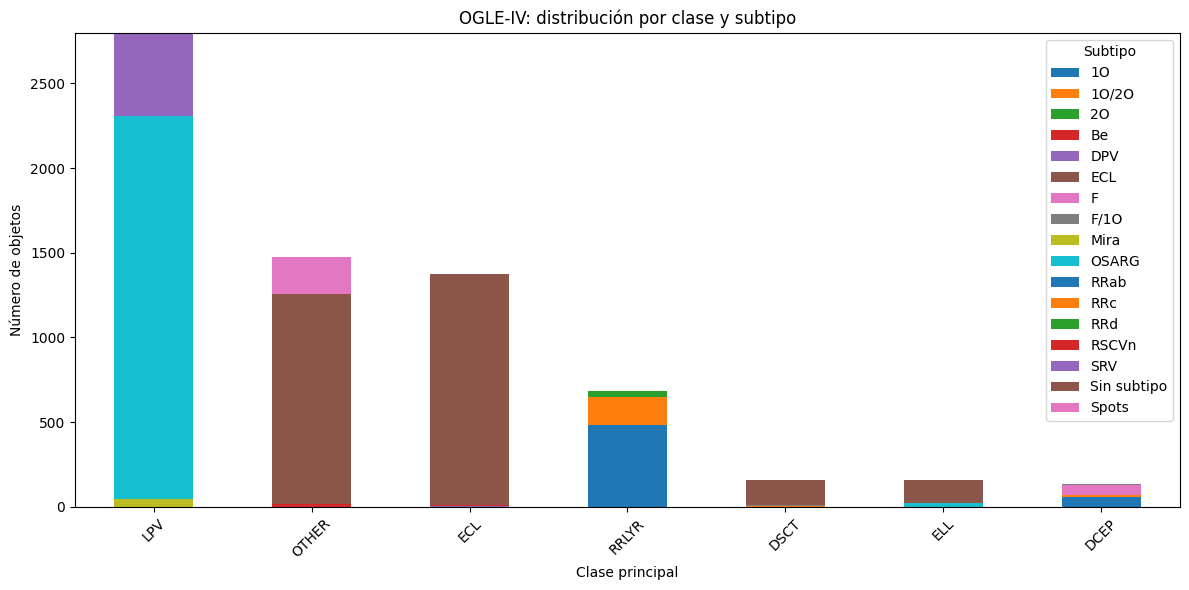

In [190]:
# Eliminar T2CEP y ACEP
df_filtered = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()
# Subtipos vacíos
df_filtered["Subtipo"] = df_filtered["Subtipo"].fillna("Sin subtipo")
# Conteos
counts = (df_filtered.groupby(["Tipo", "Subtipo"]).size().unstack(fill_value=0))
# Ordenar por abundancia
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
# Histograma apilado
ax = counts.plot(kind="bar",stacked=True,figsize=(12,6))

plt.xlabel("Clase principal")
plt.ylabel("Número de objetos")
plt.title("OGLE-IV: distribución por clase y subtipo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Eliminamos columnas innecesarias y nos preparamos para encontrar las features interesantes que mencionamos anteriormente:


Periodo


Deltas Min-Max, Max-Min, Min-Min

In [191]:
df = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()
df_sin_periodo = df[df["Periodo"].isna()].copy()
df = df[df["Periodo"].notna()].copy()
df = df.drop(columns=["RA", "DEC", "V"])
df.reset_index(drop=True, inplace=True)
print(df.head())
print(df.shape)

               ID   Tipo Subtipo       I     Periodo  Amplitud
0   LMC563.16.842  OTHER     NaN  18.925    1.850940     0.069
1  LMC563.16.1142  RRLYR    RRab  19.091    0.494447     0.839
2     LMC563.16.8    LPV   OSARG  14.662  369.000000     0.045
3  LMC563.16.9286    ECL     NaN  18.690    0.972667     0.264
4  LMC563.16.2137  OTHER     NaN  19.526    0.850470     0.142
(6705, 6)


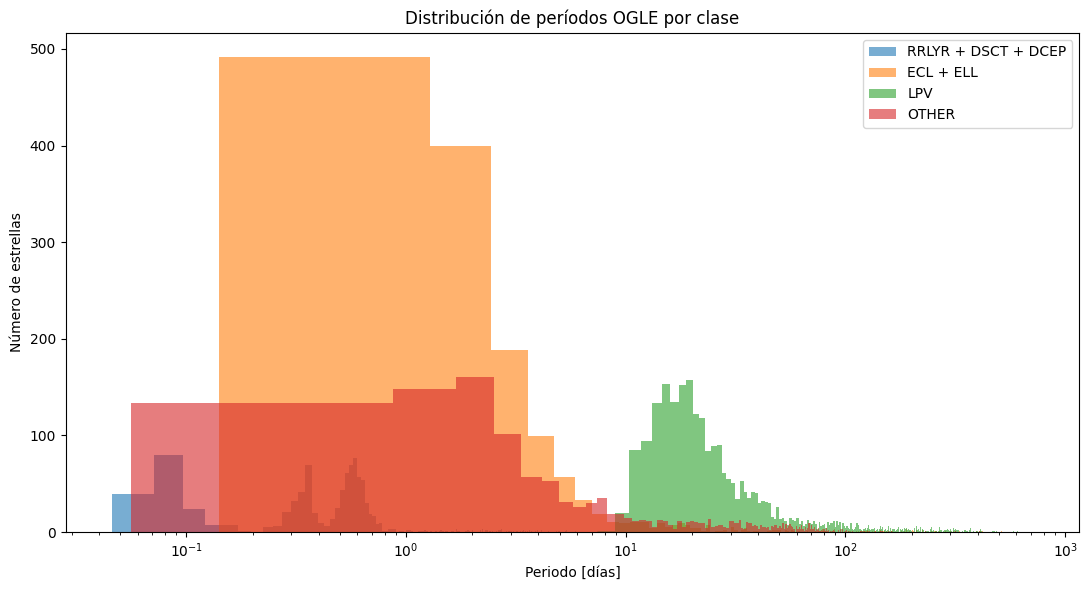

In [192]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

df_puls = df[df["Tipo"].isin(pulsantes)]
df_bin = df[df["Tipo"].isin(binarias)]
df_lpv = df[df["Tipo"].isin(lpv)]
df_other = df[df["Tipo"].isin(other)]

plt.figure(figsize=(11,6))
plt.hist(df_puls["Periodo"].dropna(),bins=500,alpha=0.6,label="RRLYR + DSCT + DCEP")
plt.hist(df_bin["Periodo"].dropna(),bins=500,alpha=0.6,label="ECL + ELL")
plt.hist(df_lpv["Periodo"].dropna(),bins=500,alpha=0.6,label="LPV")
plt.hist(df_other["Periodo"].dropna(),bins=500,alpha=0.6,label="OTHER")

plt.xscale("log")
plt.xlabel("Periodo [días]")
plt.ylabel("Número de estrellas")
plt.title("Distribución de períodos OGLE por clase")
plt.legend()
plt.tight_layout()
plt.show()

Empezar a correr desde acá cuando ya se ha hecho más de una vez, o correr desde el principio.

In [193]:
df_train, df_classify = train_test_split(df,train_size=5000,random_state=42,shuffle=True)
df_train = df_train.reset_index(drop=True)
df_classify = df_classify.reset_index(drop=True)

print("Entrenamiento:", df_train.shape)
print("Clasificación:", df_classify.shape)

Entrenamiento: (5000, 6)
Clasificación: (1705, 6)


In [194]:
PHOT_PATH = "phot/I"
def load_lightcurve(star_id):
    filepath = os.path.join(PHOT_PATH, f"{star_id}.dat")
    if not os.path.exists(filepath):
        return None, None, None
    try:
        data = np.loadtxt(filepath)
        t = data[:,0]
        mag = data[:,1]
        err = data[:,2]
        return t, mag, err
    except:
        return None, None, None

In [195]:
def lomb_scargle_period(t,mag,star_type=None,subtype=None,samples_per_peak=10):
    # -----------------------------
    # Limpiar datos
    # -----------------------------
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]
    if len(t) < 30:
        return np.nan, None, None
    # -----------------------------
    # Centrar magnitudes
    # -----------------------------
    mag = mag - np.median(mag)
    # -----------------------------
    # Rangos físicos
    # -----------------------------
    min_period = 0.05
    max_period = 1000
    if star_type == "RRLYR":
        min_period = 0.15
        max_period = 1.2
    elif star_type == "LPV":
        # Subtipos LPV
        if subtype == "OSARG":
            min_period = 5
            max_period = 100
        elif subtype == "SRV":
            min_period = 10
            max_period = 300
        elif subtype == "Mira":
            min_period = 50
            max_period = 1500
        else:
            min_period = 5
            max_period = 500
    elif star_type == "ECL":
        min_period = 0.1
        max_period = 100
    elif star_type == "DCEP":
        min_period = 0.5
        max_period = 150
    # -----------------------------
    # Frecuencias
    # -----------------------------
    max_frequency = 1/min_period
    min_frequency = max(1/max_period,1/(t.max() - t.min()))
    # -----------------------------
    # Lomb Scargle
    # -----------------------------
    ls = LombScargle(t,mag,center_data=True)
    frequency, power = ls.autopower(minimum_frequency=min_frequency,maximum_frequency=max_frequency,samples_per_peak=samples_per_peak)
    # -----------------------------
    # Ordenar TODOS los picos
    # -----------------------------
    sorted_idx = np.argsort(power)[::-1]
    aliases = [1.0, 0.5, 2.0]
    best_period = None
    for idx in sorted_idx[:50]:
        period = 1 / frequency[idx]
        # -------------------------
        # Evitar aliases
        # -------------------------
        bad_alias = False
        for alias in aliases:
            if abs(period - alias) < 0.05:
                bad_alias = True
                break
        if bad_alias:
            continue
        # -------------------------
        # Restricciones LPV
        # -------------------------
        if star_type == "LPV":
            if period < 5:
                continue
        best_period = period
        break
    # -----------------------------
    # Fallback
    # -----------------------------
    if best_period is None:
        best_period = 1 / frequency[np.argmax(power)]
    # -----------------------------
    # Eclipsantes
    # -----------------------------
    if star_type == "ECL":
        best_period *= 2
    # Detectar soluciones pegadas al borde
    if best_period > 0.95 * max_period:
        best_period = np.nan
    return best_period, frequency, power

In [196]:
def phase_fold(t, period):
    phase = (t % period) / period
    return phase

In [197]:
results = []

for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, period_grid, power = lomb_scargle_period(
            t,
            mag,
            star_type=star["Tipo"],
            subtype=star["Subtipo"])
        results.append({
            "ID": star["ID"],
            "Tipo": star["Tipo"],
            "Subtipo": star["Subtipo"],
            "Periodo_OGLE": star["Periodo"],
            "Periodo_LS": period_ls})
    except:
        continue

features_df = pd.DataFrame(results)
print(features_df)

                  ID   Tipo Subtipo  Periodo_OGLE  Periodo_LS
0       LMC570.04.20    LPV   OSARG     29.580000   29.486020
1     LMC570.22.5112    LPV   OSARG     41.370000   88.219826
2     LMC563.22.7220   DCEP   1O/2O      0.894689    0.894737
3     LMC563.16.8314    LPV   OSARG     45.890000   45.924157
4       LMC563.05.16    LPV   OSARG     70.560000   70.784780
...              ...    ...     ...           ...         ...
4995   LMC562.02.683    ECL     NaN      3.459870    3.460264
4996  LMC570.22.5125    LPV   OSARG     49.890000   50.114744
4997  LMC570.30.3312    ECL     NaN      0.959039    1.846945
4998  LMC571.12.4453  RRLYR    RRab      0.632495    0.632444
4999  LMC562.32.5326   DSCT     NaN      0.078112    0.078112

[5000 rows x 5 columns]


In [198]:
features_df["Frac_Error"] = (np.abs(features_df["Periodo_LS"] - features_df["Periodo_OGLE"]) / features_df["Periodo_OGLE"])
print(features_df["Frac_Error"].describe())

count    4.879000e+03
mean     3.825497e+00
std      1.007020e+02
min      9.225750e-09
25%      4.067367e-05
50%      4.895731e-04
75%      4.556173e-03
max      6.660255e+03
Name: Frac_Error, dtype: float64


In [199]:
bad = features_df[features_df["Frac_Error"] > 0.5]
print(len(bad))
print(bad["Tipo"].value_counts())
print(bad[["ID","Tipo","Subtipo","Periodo_OGLE","Periodo_LS","Frac_Error"]])

622
Tipo
LPV      289
ECL      134
OTHER    101
ELL       64
RRLYR     30
DCEP       4
Name: count, dtype: int64
                   ID   Tipo Subtipo  Periodo_OGLE  Periodo_LS  Frac_Error
1      LMC570.22.5112    LPV   OSARG     41.370000   88.219826    1.132459
14       LMC563.17.12    LPV   OSARG     16.150000    8.073255    0.500108
18    LMC562.26.10289  OTHER     NaN      1.960970    0.661141    0.662850
26       LMC562.24.73    LPV   OSARG     20.077000   90.150816    3.490253
38     LMC571.29.4158  OTHER     NaN     39.570000  823.772110   19.818097
...               ...    ...     ...           ...         ...         ...
4969   LMC571.30.1171    ECL     NaN      2.090075    0.675794    0.676665
4974    LMC562.23.165  OTHER     NaN     19.950000    0.949823    0.952390
4979   LMC571.11.4495    LPV   OSARG     14.161000   62.229148    3.394404
4981     LMC563.31.55    ELL     NaN    114.540000   57.206733    0.500552
4997   LMC570.30.3312    ECL     NaN      0.959039    1.846945

In [200]:
good = features_df[features_df["Frac_Error"] < 0.1]
print(len(good) / len(features_df))

0.7906


Estamos teniendo problemas con las eclipsantes(as expected), y con las LPVs, ir a mirar tantos periodos posibles nos está matando un poco...

In [201]:
def folded_lightcurve(t, mag, period):
    phase = phase_fold(t, period)
    idx = np.argsort(phase)
    phase = phase[idx]
    mag = mag[idx]
    phase2 = np.concatenate([phase,phase + 1])
    mag2 = np.concatenate([mag,mag])
    return phase2, mag2

In [202]:
def smooth_folded_curve(phase,mag,nbins=120,smooth_window=11,polyorder=3):
    bins = np.linspace(0, 2, nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    binned_mag = np.full(nbins,np.nan)

    for i in range(nbins):
        mask = ((phase >= bins[i])&(phase < bins[i+1]))
        if np.sum(mask) > 0:
            binned_mag[i] = np.median(mag[mask])
    valid = np.isfinite(binned_mag)
    x = bin_centers[valid]
    y = binned_mag[valid]
    if len(x) < 5:
        return bin_centers, binned_mag

    interp = interp1d(x,y,kind="cubic",fill_value="extrapolate")
    smooth_mag = interp(bin_centers)

    if smooth_window >= len(smooth_mag):
        smooth_window = len(smooth_mag) - 1

    if smooth_window % 2 == 0:
        smooth_window += 1

    smooth_mag = savgol_filter(smooth_mag, window_length=smooth_window,polyorder=polyorder)
    return bin_centers, smooth_mag

Cambiando de tema, lo siguiente trabaja cosas de máximos y mínimos, no parece muy útil excepto para max->min de pulsantes. Consideremos quitar esta parte.

In [203]:
def alternating_extrema_clean(phase,smooth_mag,minima_idx,maxima_idx):
    extrema = []
    for idx in minima_idx:
        extrema.append({"idx": idx,"phase": phase[idx],"mag": smooth_mag[idx],"type": "min"})
    for idx in maxima_idx:
        extrema.append({"idx": idx,"phase": phase[idx],"mag": smooth_mag[idx],"type": "max"})
    extrema = sorted(extrema,key=lambda x: x["phase"])
    cleaned = []
    for ext in extrema:
        if len(cleaned) == 0:
            cleaned.append(ext)
            continue
        last = cleaned[-1]
        if ext["type"] != last["type"]:
            cleaned.append(ext)
            continue
        if ext["type"] == "min":
            if ext["mag"] > last["mag"]:
                cleaned[-1] = ext
        else:
            if ext["mag"] < last["mag"]:
                cleaned[-1] = ext
    minima_keep = np.array([e["idx"] for e in cleaned if e["type"] == "min"])
    maxima_keep = np.array([ e["idx"] for e in cleaned if e["type"] == "max"])
    return minima_keep, maxima_keep


In [204]:
def extract_shape_features(phase,mag, n_extrema=4):
    smooth_phase, smooth_mag = smooth_folded_curve(phase,mag)
    amp = (np.percentile(smooth_mag, 95) - np.percentile(smooth_mag, 5))
    prominence = 0.15 * amp
    minima_idx, _ = find_peaks(smooth_mag,distance=10,prominence=prominence)
    maxima_idx, _ = find_peaks( -smooth_mag,distance=10,prominence=prominence)
    if (len(minima_idx) < 1 or len(maxima_idx) < 1):
        return None
    minima_idx, maxima_idx = alternating_extrema_clean(smooth_phase,smooth_mag,minima_idx,maxima_idx)
    minima_sorted = minima_idx[np.argsort(smooth_mag[minima_idx])[::-1]]
    minima_keep = minima_sorted[:n_extrema]
    maxima_sorted = maxima_idx[np.argsort(smooth_mag[maxima_idx])]
    maxima_keep = maxima_sorted[:n_extrema]
    minima_keep = minima_keep[np.argsort(smooth_phase[minima_keep])]
    maxima_keep = maxima_keep[np.argsort(smooth_phase[maxima_keep])]
    minima_phase = smooth_phase[minima_keep]
    maxima_phase = smooth_phase[maxima_keep]
    minima_mag = smooth_mag[minima_keep]
    maxima_mag = smooth_mag[maxima_keep]
    delta_min_to_max = []
    for pmin in minima_phase:
        future_max = maxima_phase[maxima_phase > pmin]
        if len(future_max) == 0:
            future_max = maxima_phase + 1
        nearest_max = future_max[0]
        delta = (nearest_max - pmin) % 1
        delta_min_to_max.append(delta)
    delta_max_to_min = []
    for pmax in maxima_phase:
        future_min = minima_phase[minima_phase > pmax]
        if len(future_min) == 0:
            future_min = minima_phase + 1
        nearest_min = future_min[0]
        delta = (nearest_min - pmax) % 1
        delta_max_to_min.append(delta)
    minima_diff = []
    for i in range(len(minima_mag) - 1):
        minima_diff.append(abs(minima_mag[i+1] - minima_mag[i]))
    maxima_diff = []
    for i in range(len(maxima_mag) - 1):
        maxima_diff.append(abs(maxima_mag[i+1] - maxima_mag[i]))
    amplitude = (np.max(minima_mag) - np.min(maxima_mag))
    return {"Amplitude": amplitude,"Mean_MinMax_Delta": np.mean(delta_min_to_max),"Mean_MaxMin_Delta":np.mean(delta_max_to_min),
            "Mean_Minima_Diff":np.mean(minima_diff) if len(minima_diff) > 0 else np.nan, "Mean_Maxima_Diff":np.mean(maxima_diff)
            if len(maxima_diff) > 0 else np.nan, "N_Minima": len(minima_keep),"N_Maxima": len(maxima_keep),
            "smooth_phase": smooth_phase, "smooth_mag": smooth_mag,"minima_idx": minima_keep,"maxima_idx": maxima_keep}

In [205]:
feature_rows = []
for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, freq, power = lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"])
        if np.isnan(period_ls):
            continue
        phase2, mag2 = folded_lightcurve(t,mag,period_ls)
        shape_features = extract_shape_features(phase2,mag2)
        if shape_features is None:
            continue
        row = {"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"],
            "Periodo_LS": period_ls,"Amplitude_OGLE": star["Amplitud"]}
        row.update(shape_features)
        feature_rows.append(row)
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue

features_df = pd.DataFrame(feature_rows)
print(features_df.head())
print(features_df.shape)

               ID  Tipo Subtipo  Periodo_LS  Amplitude_OGLE  Amplitude  \
0    LMC570.04.20   LPV   OSARG   29.486020           0.030   0.038045   
1  LMC570.22.5112   LPV   OSARG   88.219826           0.042   0.047869   
2  LMC563.22.7220  DCEP   1O/2O    0.894737           0.293   0.306054   
3  LMC563.16.8314   LPV   OSARG   45.924157           0.047   0.047256   
4    LMC563.05.16   LPV   OSARG   70.784780           0.047   0.056235   

   Mean_MinMax_Delta  Mean_MaxMin_Delta  Mean_Minima_Diff  Mean_Maxima_Diff  \
0           0.550000           0.450000      3.552714e-15      0.000000e+00   
1           0.408333           0.316667      3.010490e-03      3.562937e-03   
2           0.383333           0.616667               NaN      3.552714e-15   
3           0.233333           0.716667      1.776357e-15      1.869668e-02   
4           0.450000           0.550000      1.776357e-15      1.776357e-15   

   N_Minima  N_Maxima                                       smooth_phase  \
0   

In [206]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

feat_puls = features_df[features_df["Tipo"].isin(pulsantes)]
feat_bin = features_df[features_df["Tipo"].isin(binarias)]
feat_lpv = features_df[features_df["Tipo"].isin(lpv)]
feat_other = features_df[features_df["Tipo"].isin(other)]

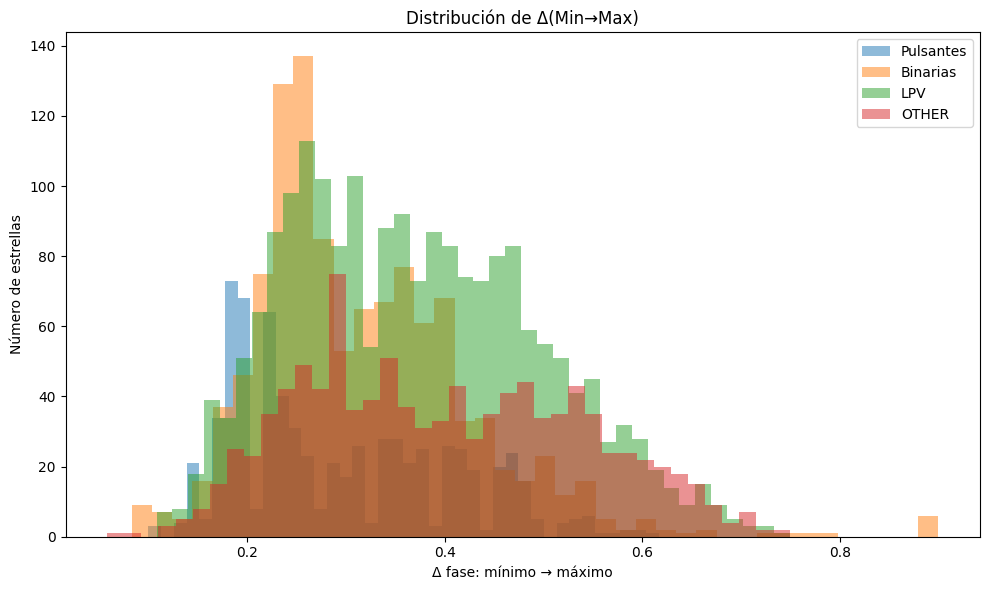

In [207]:
plt.figure(figsize=(10,6))
plt.hist(feat_puls["Mean_MinMax_Delta"].dropna(),bins=40,alpha=0.5,label="Pulsantes")
plt.hist(feat_bin["Mean_MinMax_Delta"].dropna(),bins=40,alpha=0.5,label="Binarias")
plt.hist(feat_lpv["Mean_MinMax_Delta"].dropna(),bins=40,alpha=0.5,label="LPV")
plt.hist(feat_other["Mean_MinMax_Delta"].dropna(),bins=40,alpha=0.5,label="OTHER")
plt.xlabel("Δ fase: mínimo → máximo")
plt.ylabel("Número de estrellas")
plt.title("Distribución de Δ(Min→Max)")
plt.legend()
plt.tight_layout()
plt.show()

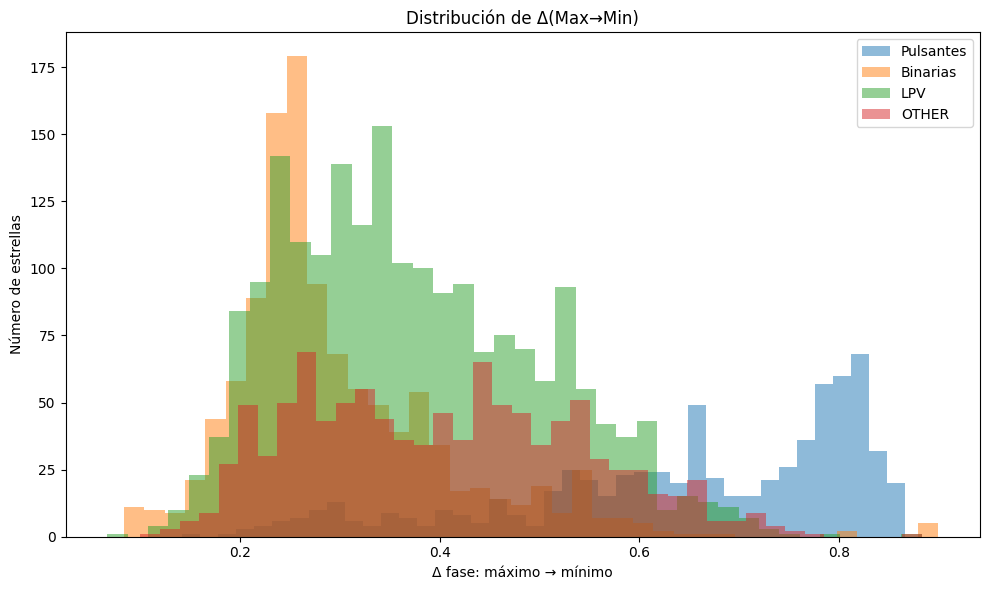

In [208]:
plt.figure(figsize=(10,6))
plt.hist(feat_puls["Mean_MaxMin_Delta"].dropna(),bins=40,alpha=0.5,label="Pulsantes")
plt.hist(feat_bin["Mean_MaxMin_Delta"].dropna(),bins=40,alpha=0.5,label="Binarias")
plt.hist(feat_lpv["Mean_MaxMin_Delta"].dropna(),bins=40,alpha=0.5,label="LPV")
plt.hist(feat_other["Mean_MaxMin_Delta"].dropna(),bins=40,alpha=0.5,label="OTHER")
plt.xlabel("Δ fase: máximo → mínimo")
plt.ylabel("Número de estrellas")
plt.title("Distribución de Δ(Max→Min)")
plt.legend()
plt.tight_layout()
plt.show()

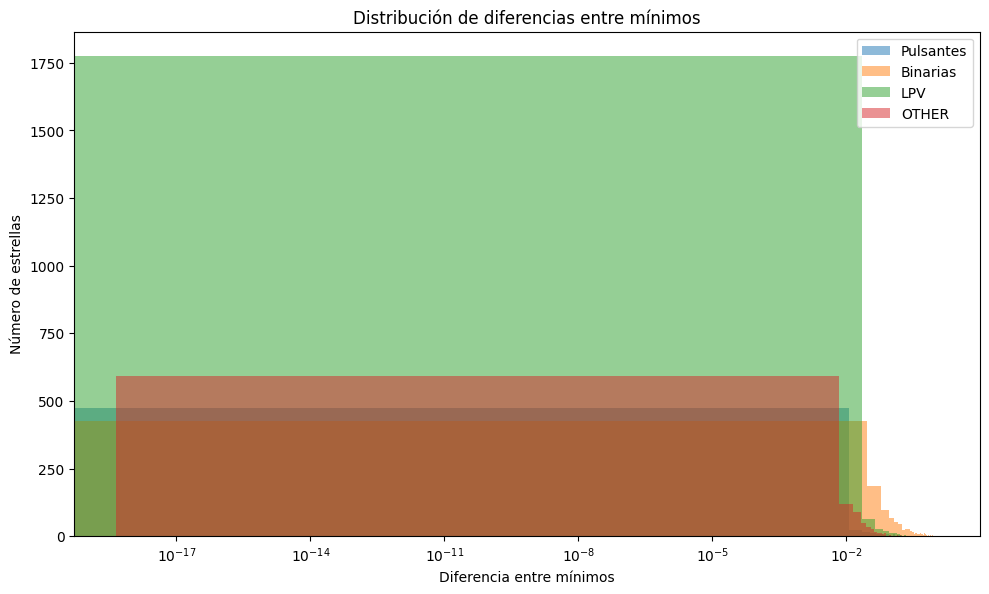

In [209]:
plt.figure(figsize=(10,6))
plt.hist(feat_puls["Mean_Minima_Diff"].dropna(),bins=40,alpha=0.5,label="Pulsantes")
plt.hist(feat_bin["Mean_Minima_Diff"].dropna(),bins=40,alpha=0.5,label="Binarias")
plt.hist(feat_lpv["Mean_Minima_Diff"].dropna(),bins=40,alpha=0.5,label="LPV")
plt.hist(feat_other["Mean_Minima_Diff"].dropna(),bins=40,alpha=0.5,label="OTHER")
plt.xlabel("Diferencia entre mínimos")
plt.ylabel("Número de estrellas")
plt.title("Distribución de diferencias entre mínimos")
plt.legend()
plt.tight_layout()
plt.xscale("log")
plt.show()

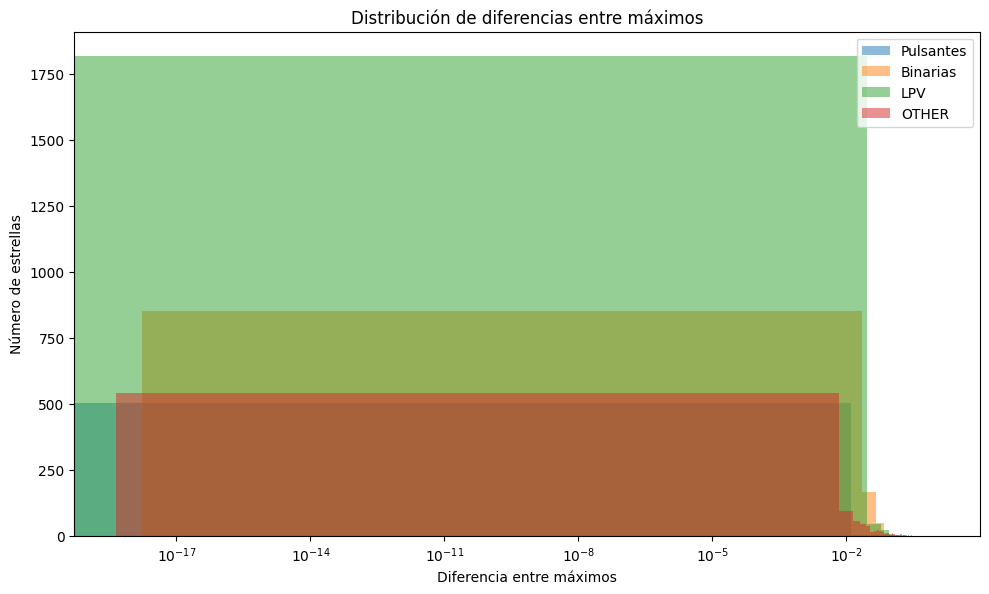

In [210]:
plt.figure(figsize=(10,6))
plt.hist(feat_puls["Mean_Maxima_Diff"].dropna(),bins=40,alpha=0.5,label="Pulsantes")
plt.hist(feat_bin["Mean_Maxima_Diff"].dropna(),bins=40,alpha=0.5,label="Binarias")
plt.hist(feat_lpv["Mean_Maxima_Diff"].dropna(),bins=40,alpha=0.5,label="LPV")
plt.hist(feat_other["Mean_Maxima_Diff"].dropna(),bins=40,alpha=0.5,label="OTHER")
plt.xlabel("Diferencia entre máximos")
plt.ylabel("Número de estrellas")
plt.title("Distribución de diferencias entre máximos")
plt.legend()
plt.tight_layout()
plt.xscale("log")
plt.show()

VAyamos con skewness

In [211]:
def extract_skewness_feature(phase,mag):
    smooth_phase, smooth_mag = smooth_folded_curve(phase,mag)
    valid = np.isfinite(smooth_mag)
    smooth_mag = smooth_mag[valid]
    if len(smooth_mag) < 10:
        return None
    amplitude = (np.percentile(smooth_mag, 95)-np.percentile(smooth_mag, 5))
    # Magnitudes:
    # menor magnitud = más brillante
    # invertimos signo para interpretación física intuitiva
    smooth_mag = (smooth_mag - np.median(smooth_mag)) / np.std(smooth_mag)
    skewness = -skew(smooth_mag)
    return {"Amplitude": amplitude,"Skewness": skewness,
        "smooth_phase": smooth_phase,"smooth_mag": smooth_mag}

In [212]:
feature_rows = []
for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, freq, power = lomb_scargle_period(t,mag,
            star_type=star["Tipo"],subtype=star["Subtipo"])
        if np.isnan(period_ls):
            continue
        phase2, mag2 = folded_lightcurve(t,mag,period_ls)
        shape_features = extract_skewness_feature(phase2,mag2)
        if shape_features is None:
            continue
        row = {"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"],"Periodo_LS": period_ls,"Amplitude_OGLE": 
               star["Amplitud"]}
        row.update(shape_features)
        feature_rows.append(row)
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue

features_df = pd.DataFrame(feature_rows)
print(features_df.head())
print(features_df.shape)

               ID  Tipo Subtipo  Periodo_LS  Amplitude_OGLE  Amplitude  \
0    LMC570.04.20   LPV   OSARG   29.486020           0.030   0.033396   
1  LMC570.22.5112   LPV   OSARG   88.219826           0.042   0.043629   
2  LMC563.22.7220  DCEP   1O/2O    0.894737           0.293   0.296197   
3  LMC563.16.8314   LPV   OSARG   45.924157           0.047   0.041934   
4    LMC563.05.16   LPV   OSARG   70.784780           0.047   0.051114   

   Skewness                                       smooth_phase  \
0 -0.004568  [0.008333333333333333, 0.025, 0.04166666666666...   
1  0.179325  [0.008333333333333333, 0.025, 0.04166666666666...   
2  0.366825  [0.008333333333333333, 0.025, 0.04166666666666...   
3 -0.457259  [0.008333333333333333, 0.025, 0.04166666666666...   
4 -0.143396  [0.008333333333333333, 0.025, 0.04166666666666...   

                                          smooth_mag  
0  [-0.8827998022114341, -0.2224263645767017, 0.2...  
1  [0.05698135298208723, 0.5368168559404533, 0.8

In [213]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

feat_puls = features_df[features_df["Tipo"].isin(pulsantes)]
feat_bin = features_df[features_df["Tipo"].isin(binarias)]
feat_lpv = features_df[features_df["Tipo"].isin(lpv)]
feat_other = features_df[features_df["Tipo"].isin(other)]   

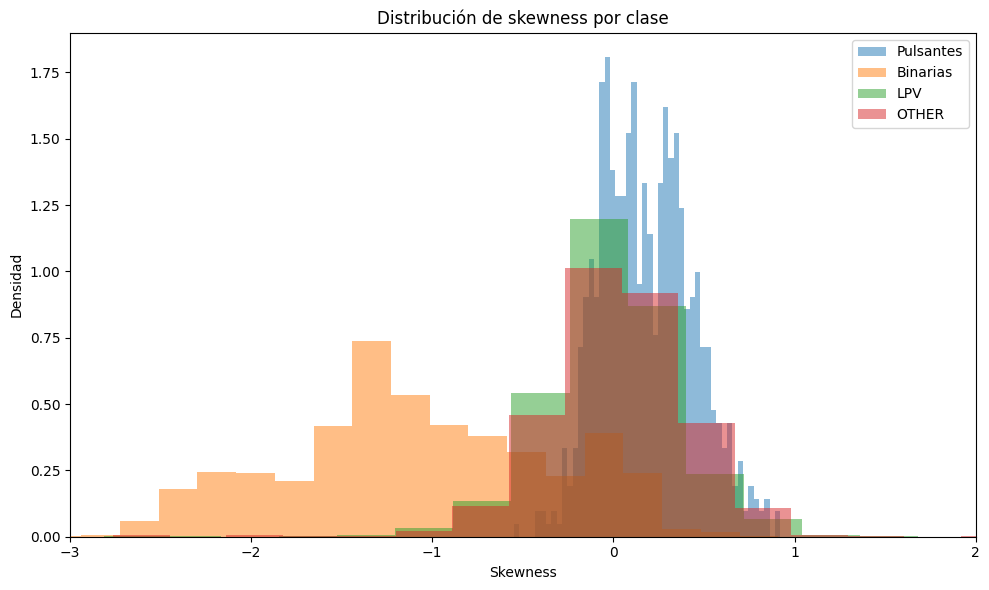

In [214]:
plt.figure(figsize=(10,6))
bins = 50
plt.hist(feat_puls["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="Pulsantes")
plt.hist(feat_bin["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="Binarias")
plt.hist(feat_lpv["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="LPV")
plt.hist(feat_other["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="OTHER")
plt.xlabel("Skewness")
plt.ylabel("Densidad")
plt.title("Distribución de skewness por clase")
plt.legend()
plt.xlim(-3, 2)
plt.tight_layout()
plt.show()

Ahora vamos con color

In [215]:
PHOT_I_PATH = "phot/I"
PHOT_V_PATH = "phot/V"

In [216]:
def load_lightcurve(star_id, band="I"):
    if band == "I":
        base_path = PHOT_I_PATH
    elif band == "V":
        base_path = PHOT_V_PATH
    else:
        return None, None, None
    filepath = os.path.join(base_path,f"{star_id}.dat")
    if not os.path.exists(filepath):
        return None, None, None
    try:
        data = np.loadtxt(filepath)
        t = data[:,0]
        mag = data[:,1]
        err = data[:,2]
        return t, mag, err
    except:
        return None, None, None

In [217]:
def extract_color_feature(star_id):
    tI, magI, errI = load_lightcurve(star_id,band="I")
    tV, magV, errV = load_lightcurve(star_id,band="V")
    if magI is None or magV is None:
        return None

    magI = magI[np.isfinite(magI)]
    magV = magV[np.isfinite(magV)]

    if len(magI) < 5 or len(magV) < 5:
        return None

    median_I = np.median(magI)
    median_V = np.median(magV)
    color_VI = median_V - median_I
    return {"Median_I": median_I,"Median_V": median_V,"Color_VI": color_VI}

In [218]:
color_rows = []
for _, star in df_train.iterrows():
    try:
        color_features = extract_color_feature(star["ID"])
        if color_features is None:
            continue
        row = {"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"]}
        row.update(color_features)
        color_rows.append(row)
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue
color_df = pd.DataFrame(color_rows)
print(color_df.head())
print(color_df.shape)

               ID  Tipo Subtipo  Median_I  Median_V  Color_VI
0    LMC570.04.20   LPV   OSARG    14.328    16.350     2.022
1  LMC570.22.5112   LPV   OSARG    14.111    16.316     2.205
2  LMC563.22.7220  DCEP   1O/2O    16.301    16.850     0.549
3  LMC563.16.8314   LPV   OSARG    14.587    16.428     1.841
4    LMC563.05.16   LPV   OSARG    13.605    15.913     2.308
(4879, 6)


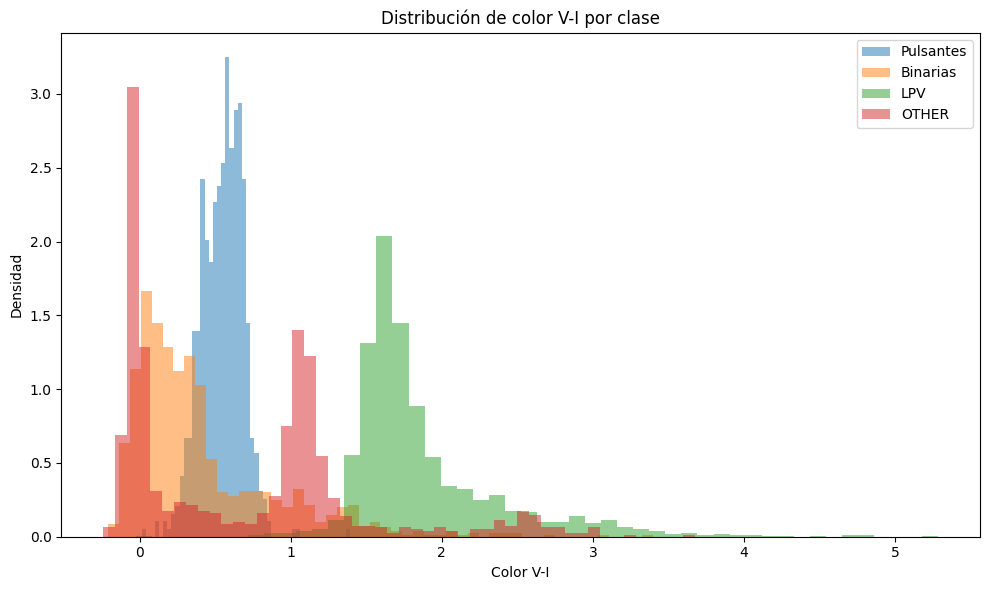

In [219]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

color_puls = color_df[color_df["Tipo"].isin(pulsantes)]
color_bin = color_df[color_df["Tipo"].isin(binarias)]
color_lpv = color_df[color_df["Tipo"].isin(lpv)]
color_other = color_df[color_df["Tipo"].isin(other)]

plt.figure(figsize=(10,6))
bins = 50
plt.hist(color_puls["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="Pulsantes")
plt.hist(color_bin["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="Binarias")
plt.hist(color_lpv["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="LPV")
plt.hist(color_other["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="OTHER")
plt.xlabel("Color V-I")
plt.ylabel("Densidad")
plt.title("Distribución de color V-I por clase")
plt.legend()
plt.tight_layout()
plt.show()

In [220]:
merged_df = pd.merge(features_df[["ID","Tipo","Periodo_LS","Skewness"]],color_df[["ID","Color_VI"]],on="ID",how="inner")
print(merged_df.head())
print(merged_df.shape)
merged_df = merged_df.replace([np.inf, -np.inf],np.nan)
merged_df = merged_df.dropna()
print(merged_df.shape)
merged_df["LogPeriod"] = np.log10(merged_df["Periodo_LS"])

               ID  Tipo  Periodo_LS  Skewness  Color_VI
0    LMC570.04.20   LPV   29.486020 -0.004568     2.022
1  LMC570.22.5112   LPV   88.219826  0.179325     2.205
2  LMC563.22.7220  DCEP    0.894737  0.366825     0.549
3  LMC563.16.8314   LPV   45.924157 -0.457259     1.841
4    LMC563.05.16   LPV   70.784780 -0.143396     2.308
(4760, 5)
(4760, 5)


In [221]:
def simplify_class(tipo):
    if tipo in ["RRLYR", "DSCT", "DCEP"]:
        return "Pulsantes"
    elif tipo in ["ECL", "ELL"]:
        return "Binarias"
    elif tipo == "LPV":
        return "LPV"
    else:
        return "OTHER"
# Nueva columna
merged_df["Grupo"] = merged_df["Tipo"].apply(simplify_class)

In [222]:
merged_df_plot = merged_df[merged_df["Grupo"] != "OTHER"].copy()
print(merged_df_plot["Grupo"].value_counts())

Grupo
LPV          1953
Binarias     1097
Pulsantes     689
Name: count, dtype: int64


In [223]:
fig = px.scatter_3d(merged_df,x="LogPeriod",y="Skewness",z="Color_VI",color="Grupo",opacity=0.7,
    title=("Espacio de features:\n""Periodo + Skewness + Color"),
    labels={"LogPeriod": "log10(Periodo)","Skewness": "Skewness","Color_VI": "Color V-I", "Grupo": "Clase"},
    hover_data=["ID", "Tipo"])

fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(xaxis_title="log10(Periodo)",yaxis_title="Skewness",zaxis_title="Color V-I"))
fig.show()

In [224]:
def extract_maxmin_feature(phase,mag):
    """Amplitud fotométrica robusta: max(mag)-min(mag)
    usando percentiles."""
    smooth_phase, smooth_mag = (smooth_folded_curve(phase,mag))
    valid = np.isfinite(smooth_mag)
    smooth_mag = (smooth_mag[valid])
    if len(smooth_mag) < 10:
        return None
    max_mag = np.percentile(smooth_mag,95)
    min_mag = np.percentile(smooth_mag,5)
    delta_maxmin = (max_mag - min_mag)
    return {"Delta_MaxMin": delta_maxmin,"smooth_phase":smooth_phase,"smooth_mag":smooth_mag}

In [225]:
feature_rows = []

for _, star in df_train.iterrows():
    try:
        t, mag, err = (load_lightcurve(star["ID"]))
        if t is None:
            continue
        period_ls, _, _ = (lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"]))
        if np.isnan(period_ls):
            continue
        phase2, mag2 = (folded_lightcurve(t,mag,period_ls))
        feat = (extract_maxmin_feature(phase2,mag2))
        if feat is None:
            continue
        feature_rows.append({"ID":star["ID"],"Tipo":star["Tipo"],"Periodo_LS":period_ls,"Delta_MaxMin":feat["Delta_MaxMin"]})
    except:
        continue

amp_df = pd.DataFrame(feature_rows)
print(amp_df.shape)
amp_df.head()

(4879, 4)


,ID,Tipo,Periodo_LS,Delta_MaxMin
0,LMC570.04.20,LPV,29.486020,0.033396
1,LMC570.22.5112,LPV,88.219826,0.043629
2,LMC563.22.7220,DCEP,0.894737,0.296197
3,LMC563.16.8314,LPV,45.924157,0.041934
4,LMC563.05.16,LPV,70.784780,0.051114


In [226]:
merged_amp = pd.merge(amp_df,color_df[["ID", "Color_VI"]],on="ID",how="inner")
merged_amp = (merged_amp.replace([np.inf,-np.inf],np.nan).dropna())
merged_amp["LogPeriod"] = np.log10(merged_amp["Periodo_LS"])

In [227]:
def simplify_class(tipo):
    if tipo in ["RRLYR","DSCT","DCEP"]:
        return "Pulsantes"
    elif tipo in ["ECL","ELL"]:
        return "Binarias"
    elif tipo == "LPV":
        return "LPV"
    else:
        return "OTHER"
merged_amp["Grupo"] = (merged_amp["Tipo"].apply(simplify_class))
plot_df = (merged_amp[merged_amp["Grupo"] !="OTHER"])

In [228]:
fig = px.scatter_3d(plot_df,x="LogPeriod",y="Delta_MaxMin",z="Color_VI",color="Grupo",opacity=0.65,
    hover_data=["ID","Tipo"],title=("Periodo + Δ(Max−Min) + Color"),
    labels={"LogPeriod":"log10(Periodo)","Delta_MaxMin":"Δ(Max−Min)","Color_VI":"Color V-I"})
fig.update_traces( marker=dict(size=4))
fig.update_layout(scene=dict(xaxis_title="log10(Periodo)", yaxis_title="Δ(Max−Min)",zaxis_title="Color V-I"))
fig.show()

Machine learning

In [ ]:
rf_df = pd.merge(merged_df[["ID","Tipo","Periodo_LS","Skewness","Color_VI"]],amp_df[["ID","Delta_MaxMin"]],on="ID",how="inner")
rf_df = rf_df.replace([np.inf,-np.inf],np.nan)
rf_df = rf_df.dropna()
rf_df["LogPeriod"] = np.log10(rf_df["Periodo_LS"])
print(rf_df.head())
print(rf_df.shape)

               ID  Tipo  Periodo_LS  Skewness  Color_VI  Delta_MaxMin  \
0    LMC570.04.20   LPV   29.486020 -0.004568     2.022      0.033396   
1  LMC570.22.5112   LPV   88.219826  0.179325     2.205      0.043629   
2  LMC563.22.7220  DCEP    0.894737  0.366825     0.549      0.296197   
3  LMC563.16.8314   LPV   45.924157 -0.457259     1.841      0.041934   
4    LMC563.05.16   LPV   70.784780 -0.143396     2.308      0.051114   

   LogPeriod  
0   1.469616  
1   1.945566  
2  -0.048305  
3   1.662041  
4   1.849940  
(4760, 7)


In [260]:
def simplify_class(tipo):
    if tipo in ["RRLYR","DSCT","DCEP"]:
        return "Pulsantes"
    elif tipo in ["ECL","ELL"]:
        return "Binarias"
    elif tipo == "LPV":
        return "LPV"
    else:
        return "OTHER"
rf_df["Grupo"] = rf_df["Tipo"].apply(simplify_class)
print(rf_df["Grupo"].value_counts())

Grupo
LPV          1953
Binarias     1097
OTHER        1021
Pulsantes     689
Name: count, dtype: int64


In [261]:
feature_cols = ["LogPeriod","Delta_MaxMin","Skewness","Color_VI"]
X = rf_df[feature_cols]
y = rf_df["Grupo"]

In [262]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(3808, 4)
(952, 4)


In [263]:
rf = RandomForestClassifier(n_estimators=500,max_depth=None,min_samples_split=4,min_samples_leaf=2,
    random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [264]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

In [265]:
acc = accuracy_score(y_test,y_pred)
print(f"Accuracy = {acc:.4f}")
print("\n")
print(classification_report(y_test,y_pred))

Accuracy = 0.9370


              precision    recall  f1-score   support

    Binarias       0.92      0.88      0.90       219
         LPV       0.99      0.98      0.99       391
       OTHER       0.87      0.90      0.88       204
   Pulsantes       0.92      0.95      0.94       138

    accuracy                           0.94       952
   macro avg       0.92      0.93      0.93       952
weighted avg       0.94      0.94      0.94       952



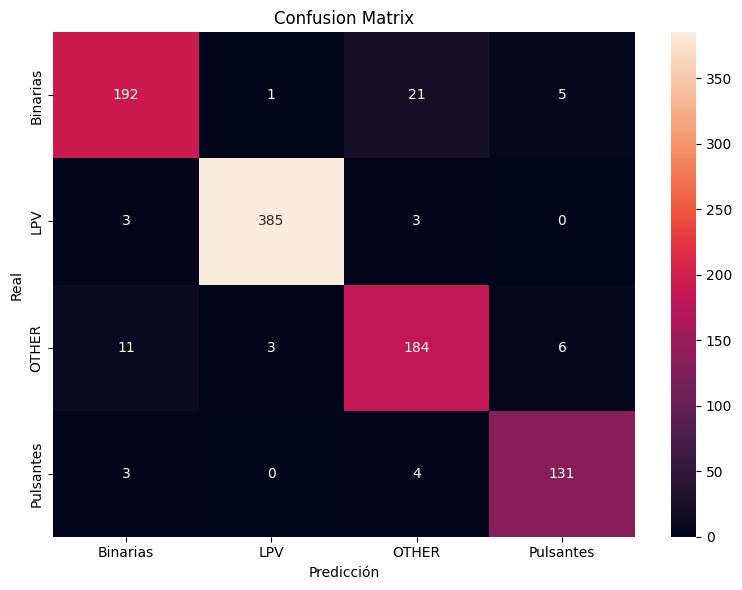

In [266]:
cm = confusion_matrix(y_test,y_pred,labels=rf.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=rf.classes_,yticklabels=rf.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [267]:
importance = pd.DataFrame({"Feature": feature_cols,"Importance": rf.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)
print(importance)

        Feature  Importance
3      Color_VI    0.345429
0     LogPeriod    0.253319
2      Skewness    0.220368
1  Delta_MaxMin    0.180884


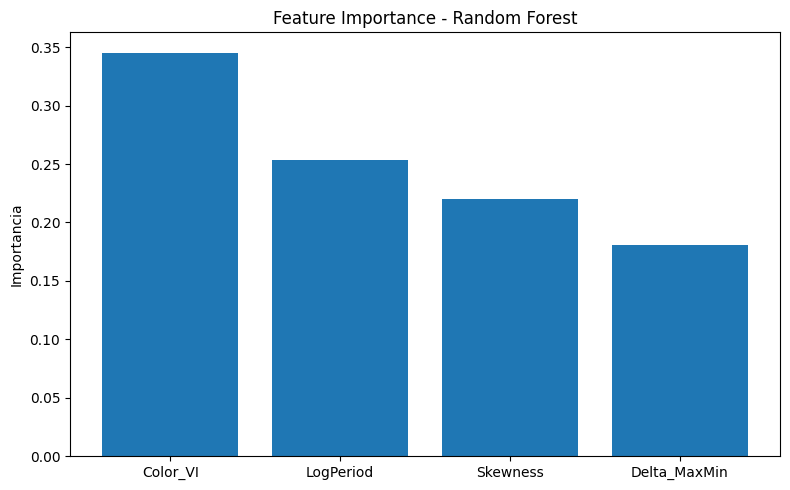

In [268]:
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"],importance["Importance"])
plt.ylabel("Importancia")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [269]:
test_plot = X_test.copy()
test_plot["True"] = y_test.values
test_plot["Predicted"] = y_pred
fig = px.scatter_3d(test_plot,x="LogPeriod",y="Skewness",z="Color_VI",color="Predicted",symbol="True",
    opacity=0.7,title="Clasificación Random Forest")
fig.show()

In [270]:
test_plot = X_test.copy()

test_plot["True"] = y_test.values
test_plot["Predicted"] = y_pred

# ---------------------------------------
# eliminar OTHER
# ---------------------------------------

test_plot = test_plot[
    test_plot["True"] != "OTHER"
].copy()

fig = px.scatter_3d(
    test_plot,
    x="LogPeriod",
    y="Skewness",
    z="Color_VI",
    color="Predicted",
    symbol="True",
    opacity=0.7,
    title="Clasificación RF (sin OTHER)",
    hover_data=["True","Predicted"]
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    scene=dict(
        xaxis_title="log10(Periodo)",
        yaxis_title="Skewness",
        zaxis_title="Color V-I"
    )
)

fig.show()

In [271]:
rf_final = RandomForestClassifier(n_estimators=500,random_state=40,n_jobs=-1)
rf_final.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [272]:
unknown_df = df_classify.copy()

In [273]:
def lomb_scargle_period_2(t,mag,samples_per_peak=10,min_period=0.05,max_period=1000,n_peaks=50):
    """Lomb-Scargle completamente agnóstico:NO usa Tipo ni Subtipo.
    Parámetros
    ----------
    t : array
        tiempos
    mag : array
        magnitudes
    samples_per_peak : int
        resolución del periodograma
    min_period : float
        periodo mínimo [días]
    max_period : float
        periodo máximo [días]
    n_peaks : int
        número de picos candidatos a revisar
    Retorna
    best_period : float
        mejor periodo encontrado
    frequency : array
        grid de frecuencias
    power : array
        poder LS
    """
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]
    if len(t) < 30:
        return np.nan, None, None
    mag = mag - np.median(mag)
    max_frequency = 1 / min_period
    min_frequency = max(1 / max_period, 1 / (t.max() - t.min()))
    ls = LombScargle(t,mag,center_data=True)
    frequency, power = ls.autopower( minimum_frequency=min_frequency,maximum_frequency=max_frequency,samples_per_peak=samples_per_peak)
    sorted_idx = np.argsort(power)[::-1]
    # aliases típicos observacionales
    aliases = [1.0, 0.5, 2.0]
    best_period = None
    for idx in sorted_idx[:n_peaks]:
        period = 1 / frequency[idx]
        bad_alias = False
        for alias in aliases:
            if abs(period - alias) < 0.05:
                bad_alias = True
                break
        if bad_alias:
            continue
        if period > 0.95 * max_period:
            continue
        if period < 1.05 * min_period:
            continue
        best_period = period
        break
    if best_period is None:
        best_period = 1 / frequency[np.argmax(power)]
    return best_period, frequency, power

In [274]:
unknown_rows = []
for _, star in df_classify.iterrows():
    try:
        t, mag, err = load_lightcurve(star["ID"])
        if t is None:
            continue
        period_ls, _, _ = lomb_scargle_period_2(t,mag)
        if np.isnan(period_ls):
            continue
        phase2, mag2 = folded_lightcurve(t,mag,period_ls)
        skew_feat = extract_skewness_feature(phase2,mag2)
        if skew_feat is None:
            continue
        amp_feat = extract_maxmin_feature(phase2, mag2)
        if amp_feat is None:
            continue
        color_feat = extract_color_feature(star["ID"])
        if color_feat is None:
            continue
        unknown_rows.append({"ID": star["ID"],"Periodo_LS": period_ls,"LogPeriod": np.log10(period_ls),"Skewness": skew_feat["Skewness"],
                             "Delta_MaxMin": amp_feat["Delta_MaxMin"], "Color_VI": color_feat["Color_VI"]})
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue

In [275]:
unknown_features_df = pd.DataFrame(unknown_rows)
print(unknown_features_df.shape)
print(unknown_features_df.head())

(1652, 6)
                ID  Periodo_LS  LogPeriod  Skewness  Delta_MaxMin  Color_VI
0  LMC562.14.12289    0.838540  -0.076476  0.622432      0.086823    0.0105
1   LMC570.29.4714   43.817673   1.641649  0.256212      0.046516    1.6120
2   LMC563.32.1478    0.727782  -0.137998 -1.472721      0.505721    0.2400
3      LMC570.29.6  205.943062   2.313747  0.172956      1.088679    2.5360
4   LMC562.11.9517  374.446036   2.573389 -0.487134      0.028016    1.5490


In [276]:
X_unknown = unknown_features_df[feature_cols].copy()

In [277]:
pred_labels = rf_final.predict(X_unknown)
pred_probs = rf_final.predict_proba(X_unknown)

In [278]:
max_prob = np.max(pred_probs,axis=1)
results_unknown = unknown_features_df.copy()
results_unknown["Predicted_Class"] = pred_labels
results_unknown["Confidence"] = max_prob

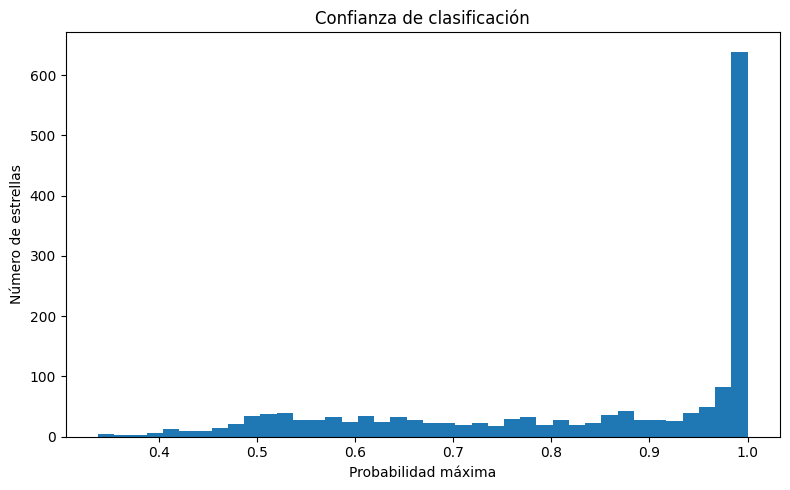

In [279]:
plt.figure(figsize=(8,5))
plt.hist(max_prob,bins=40)
plt.xlabel("Probabilidad máxima")
plt.ylabel("Número de estrellas")
plt.title("Confianza de clasificación")
plt.tight_layout()
plt.show()

In [280]:
uncertain = results_unknown.sort_values("Confidence")
print(uncertain[["ID", "Predicted_Class","Confidence"]].head(20))

                   ID Predicted_Class  Confidence
954    LMC562.19.8122        Binarias       0.338
172   LMC562.16.12068           OTHER       0.344
711    LMC562.19.8152        Binarias       0.348
22       LMC562.09.46           OTHER       0.354
828    LMC570.17.3976           OTHER       0.360
1499     LMC571.22.20             LPV       0.362
1441     LMC571.09.51           OTHER       0.366
463   LMC562.07.12094        Binarias       0.374
1556     LMC563.11.31        Binarias       0.382
616    LMC570.32.4250           OTHER       0.384
471    LMC571.10.1155       Pulsantes       0.388
236    LMC570.11.5279           OTHER       0.388
394      LMC562.12.29             LPV       0.394
220    LMC562.08.7958             LPV       0.396
1358     LMC570.27.52           OTHER       0.398
1308     LMC562.27.54        Binarias       0.400
1643      LMC563.22.9             LPV       0.404
368    LMC563.02.7329        Binarias       0.406
615    LMC562.09.8214           OTHER       0.408


In [281]:
fig = px.scatter_3d(results_unknown,x="LogPeriod",y="Skewness",z="Color_VI",color="Predicted_Class",opacity=0.7,
    hover_data=["ID","Confidence"],title="Clasificación final")
fig.update_traces(marker=dict(size=4))
fig.show()

                ID  Periodo_LS  LogPeriod  Skewness  Delta_MaxMin  Color_VI  \
0  LMC562.14.12289    0.838540  -0.076476  0.622432      0.086823    0.0105   
1   LMC570.29.4714   43.817673   1.641649  0.256212      0.046516    1.6120   
2   LMC563.32.1478    0.727782  -0.137998 -1.472721      0.505721    0.2400   
3      LMC570.29.6  205.943062   2.313747  0.172956      1.088679    2.5360   
4   LMC562.11.9517  374.446036   2.573389 -0.487134      0.028016    1.5490   

  Predicted_Class  Confidence True_Class  
0           OTHER       0.872      OTHER  
1             LPV       0.972        LPV  
2        Binarias       0.998        ECL  
3             LPV       1.000        LPV  
4           OTHER       0.606        LPV  
(1652, 9)


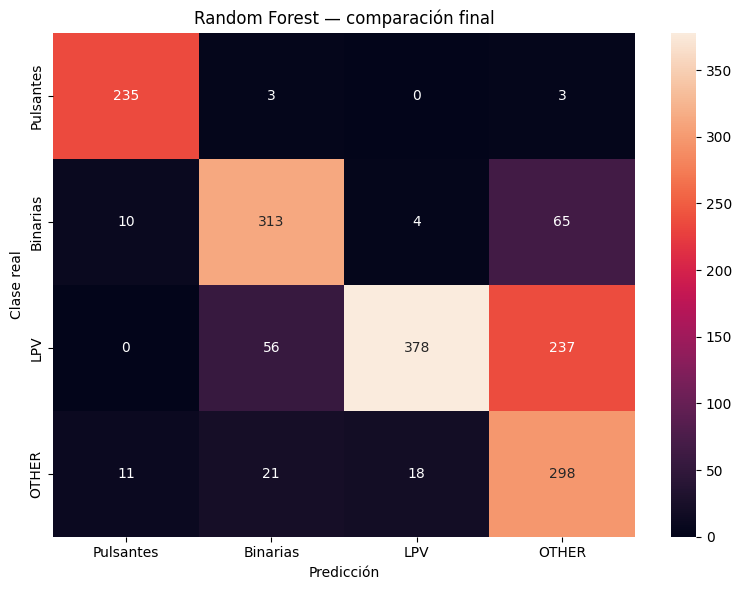

In [282]:
# COMPARAR PREDICCIÓN VS CLASE REAL

comparison_df = pd.merge(results_unknown,df_classify[["ID", "Tipo"]],on="ID",how="inner")
comparison_df = comparison_df.rename(columns={"Tipo": "True_Class"})
print(comparison_df.head())
print(comparison_df.shape)

# MATRIZ DE CONFUSIÓN

labels_order = ["Pulsantes", "Binarias", "LPV", "OTHER"]
cm = confusion_matrix(comparison_df["True_Class"].apply(simplify_class),comparison_df["Predicted_Class"],labels=labels_order)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=labels_order,yticklabels=labels_order)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Random Forest — comparación final")
plt.tight_layout()
plt.show()

Comparar estos problemas con los de Lomb Scargle iniciales, a ver si puede haber correlación

In [283]:
y_true = comparison_df["True_Class"].apply(simplify_class)
y_pred = comparison_df["Predicted_Class"]
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy final = {acc:.4f}")


Accuracy final = 0.7409


In [284]:
print("\nClassification report:\n")
print(classification_report(y_true,y_pred))


Classification report:

              precision    recall  f1-score   support

    Binarias       0.80      0.80      0.80       392
         LPV       0.94      0.56      0.71       671
       OTHER       0.49      0.86      0.63       348
   Pulsantes       0.92      0.98      0.95       241

    accuracy                           0.74      1652
   macro avg       0.79      0.80      0.77      1652
weighted avg       0.81      0.74      0.75      1652



In [285]:
wrong = comparison_df[y_true != y_pred].copy()
print("\nNúmero de errores:")
print(len(wrong))
print("\nErrores por clase real:")
print(wrong["True_Class"].apply(simplify_class).value_counts())
print("\nPrimeros errores:")
print(wrong[["ID","True_Class","Predicted_Class","Confidence","LogPeriod","Skewness","Delta_MaxMin","Color_VI"]].head(20))


Número de errores:
428

Errores por clase real:
True_Class
LPV          293
Binarias      79
OTHER         50
Pulsantes      6
Name: count, dtype: int64

Primeros errores:
                 ID True_Class Predicted_Class  Confidence  LogPeriod  \
4    LMC562.11.9517        LPV           OTHER       0.606   2.573389   
19  LMC562.15.13677        ECL           OTHER       0.560   1.249294   
22     LMC562.09.46        LPV           OTHER       0.354   2.554084   
25     LMC570.28.42        LPV           OTHER       0.538  -0.026747   
27   LMC562.19.8142        LPV           OTHER       0.512   0.029942   
30     LMC571.20.23      OTHER             LPV       0.964   1.113033   
37     LMC570.17.40        LPV           OTHER       0.572  -0.023187   
38     LMC562.27.58        LPV        Binarias       0.584   2.535601   
48   LMC563.24.7319        LPV           OTHER       0.456  -0.478116   
50  LMC562.16.12016        LPV        Binarias       0.576  -0.478026   
56   LMC570.17.4030     

In [286]:
comparison_df["Correct"] = (y_true == y_pred)
fig = px.scatter_3d(comparison_df,x="LogPeriod",y="Skewness",z="Color_VI",color="Predicted_Class",symbol="Correct",opacity=0.7,
    hover_data=[ "ID","True_Class","Predicted_Class","Confidence"],title="Predicción vs clase real")
fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(xaxis_title="log10(Periodo)", yaxis_title="Skewness",zaxis_title="Color V-I"))
fig.show()

In [287]:
wrong["True_Group"] = (wrong["True_Class"].apply(simplify_class))
confusions = ( wrong.groupby(["True_Group", "Predicted_Class"]).size().reset_index(name="Count").sort_values("Count", ascending=False))
print(confusions.head(20))

  True_Group Predicted_Class  Count
4        LPV           OTHER    237
1   Binarias           OTHER     65
3        LPV        Binarias     56
5      OTHER        Binarias     21
6      OTHER             LPV     18
7      OTHER       Pulsantes     11
2   Binarias       Pulsantes     10
0   Binarias             LPV      4
8  Pulsantes        Binarias      3
9  Pulsantes           OTHER      3


In [288]:
end_time = time.time()
elapsed = end_time - start_time
print(f"Tiempo total: {elapsed:.2f} segundos")
print(f"Tiempo total: {elapsed/60:.2f} minutos")
print(f"Tiempo total: {elapsed/3600:.2f} horas")

Tiempo total: 2141.81 segundos
Tiempo total: 35.70 minutos
Tiempo total: 0.59 horas
